<a href="https://colab.research.google.com/github/SamShinwari/Advanced-AI-Bootcamp-2026/blob/main/SingleLayerPerceptron_Improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Two classes
X = torch.tensor([
    [1., 1.],
    [2., 1.],
    [2., 2.],
    [3., 2.],
    [6., 5.],
    [7., 6.],
    [8., 6.],
    [9., 7.]
])

y = torch.tensor([
    [0.],
    [0.],
    [0.],
    [0.],
    [1.],
    [1.],
    [1.],
    [1.]
])

In [3]:
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

In [4]:
model = Perceptron()

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [6]:
epochs = 1000

losses = []

for epoch in range(epochs):

    outputs = model(X)

    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")

Epoch 100, Loss = 0.2401
Epoch 200, Loss = 0.1584
Epoch 300, Loss = 0.1177
Epoch 400, Loss = 0.0937
Epoch 500, Loss = 0.0779
Epoch 600, Loss = 0.0668
Epoch 700, Loss = 0.0585
Epoch 800, Loss = 0.0521
Epoch 900, Loss = 0.0469
Epoch 1000, Loss = 0.0428


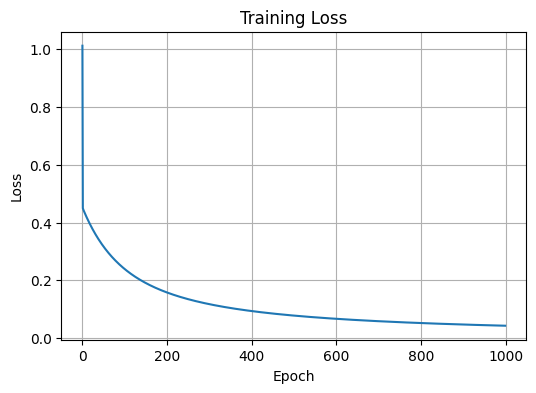

In [7]:
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

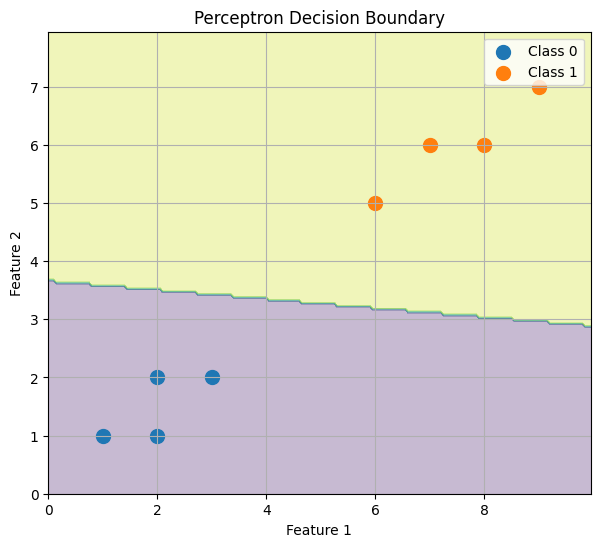

In [8]:
# Convert tensors to NumPy
X_np = X.numpy()
y_np = y.numpy()

# Create a mesh grid
x_min, x_max = X_np[:,0].min()-1, X_np[:,0].max()+1
y_min, y_max = X_np[:,1].min()-1, X_np[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.05),
    np.arange(y_min, y_max, 0.05)
)

# Predict every point in the mesh
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.FloatTensor(grid)

with torch.no_grad():
    predictions = model(grid_tensor)
    predictions = (predictions >= 0.5).float()

Z = predictions.numpy().reshape(xx.shape)

# Plot
plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_np[y_np[:,0]==0][:,0],
    X_np[y_np[:,0]==0][:,1],
    label="Class 0",
    s=100
)

plt.scatter(
    X_np[y_np[:,0]==1][:,0],
    X_np[y_np[:,0]==1][:,1],
    label="Class 1",
    s=100
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Perceptron Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()